In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Mall_Customers.csv')
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


### Data Preprocessing

In [4]:
print (df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

No missing (or, null) values in the dataset

In [6]:
# Handling categorical variables (Gender column)
# Male -> 0, Female -> 1
df['Gender'] = df['Gender'].map ({'Male' : 0, 'Female' : 1})

In [7]:
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40
5,6,1,22,17,76
6,7,1,35,18,6
7,8,1,23,18,94
8,9,0,64,19,3
9,10,1,30,19,72


In [8]:
# Scale numerical columns
scaler = StandardScaler()
df_scaled = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
df_scaled = scaler.fit_transform(df_scaled)

### EDA

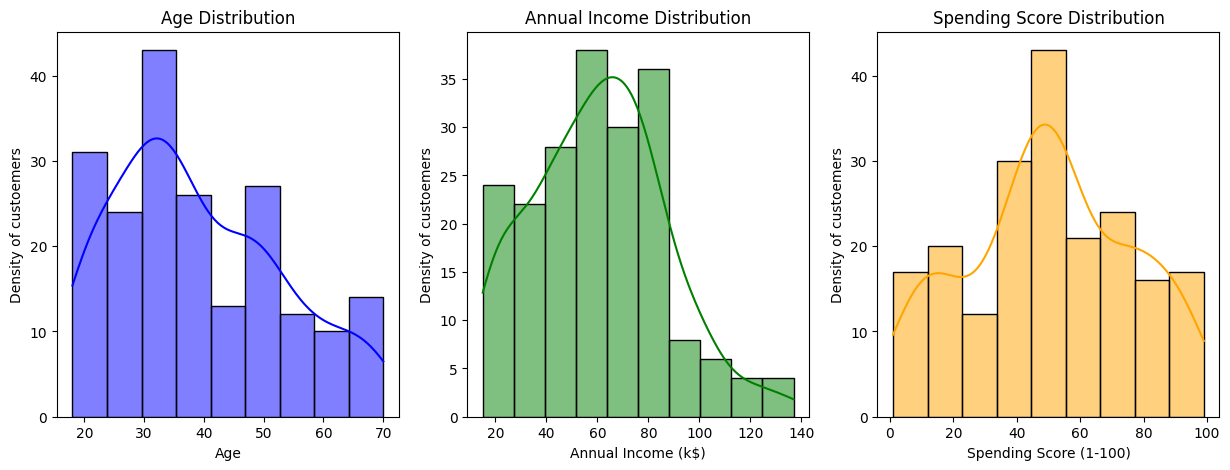

In [9]:
# Plot distribution of Age, Annual income, Spending Score
fig, axes = plt.subplots (1, 3, figsize = (15, 5))

sns.histplot(df['Age'], kde = True, ax = axes[0], color = 'blue')
axes[0].set_title ('Age Distribution')
axes[0].set_ylabel('Density of custoemers') 

sns.histplot(df['Annual Income (k$)'], kde = True, ax = axes[1], color = 'green')
axes[1].set_title ('Annual Income Distribution')
axes[1].set_ylabel('Density of custoemers') 

sns.histplot(df['Spending Score (1-100)'], kde = True, ax = axes[2], color = 'orange')
axes[2].set_title ('Spending Score Distribution')
axes[2].set_ylabel('Density of custoemers') 

plt.show()

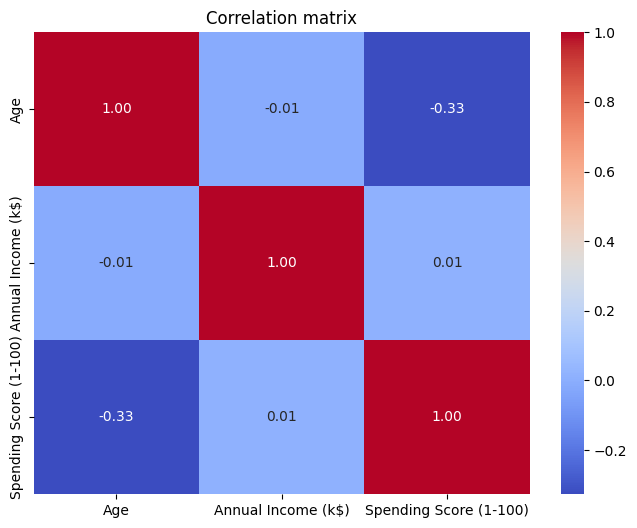

In [10]:
# Correlation matrix
plt.figure (figsize = (8, 6))
sns.heatmap (df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr(), annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title ('Correlation matrix')
plt.show()

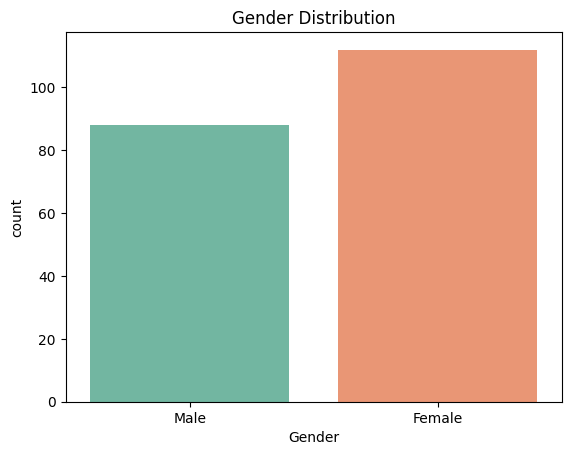

In [11]:
# Gender Distribution
sns.countplot (data = df, x = 'Gender', hue = 'Gender', palette='Set2', legend = False)
plt.title ('Gender Distribution')
plt.xticks(ticks=[0, 1], labels=['Male', 'Female'])
plt.show()

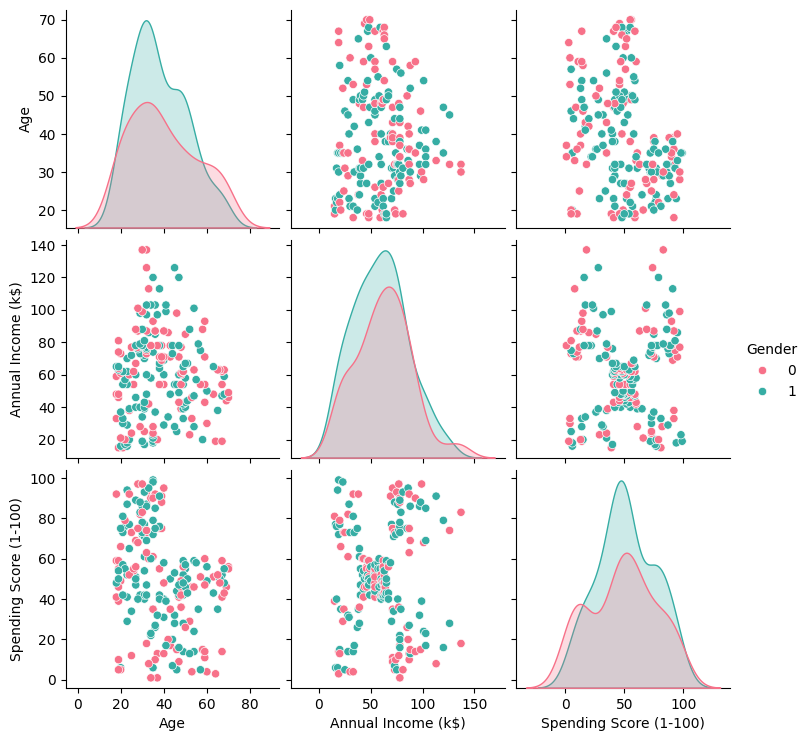

In [12]:
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']], hue = 'Gender', palette = 'husl')
plt.show()

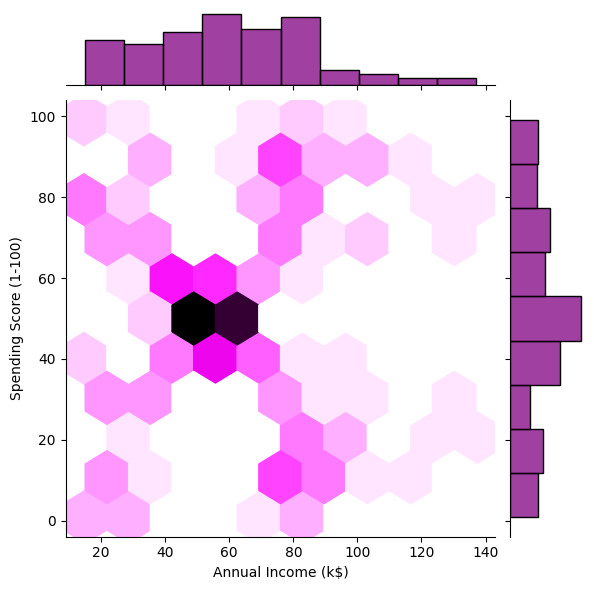

In [13]:
# Annual Income vs Spending Score
sns.jointplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', kind='hex', color='purple')
plt.show()

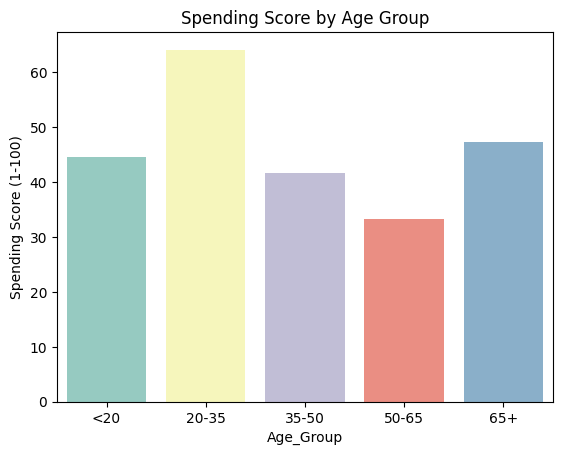

In [14]:
bins = [0, 20, 35, 50, 65, 100]
labels = ['<20', '20-35', '35-50', '50-65', '65+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

sns.barplot(data=df, x='Age_Group', y='Spending Score (1-100)', hue = 'Age_Group', errorbar=None, palette='Set3')
plt.title('Spending Score by Age Group')
plt.show()

### K-Means Clustering

In [15]:
# Determine optimal no. of clusters using Elbow method
wcss = []
for i in range (1, 11) :
    kmeans = KMeans(n_clusters = i, random_state = 42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

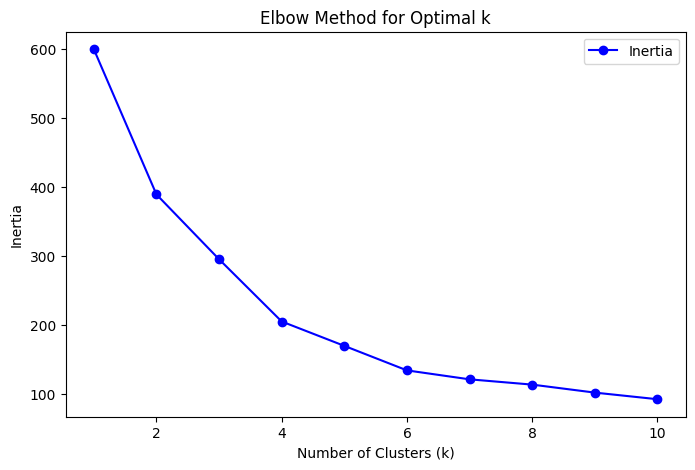

In [16]:
# Plotting the Elbow curve
plt.figure (figsize = (8, 5))
plt.plot (range (1, 11), wcss, marker = 'o', label = 'Inertia', color = 'blue')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.legend()
plt.show()

In [17]:
# Determine optimal no. of clusters using Silhouette score
from sklearn.metrics import silhouette_score

silhouette_scores = []

for i in range (2, 11) : # Silhoutte score can't be calculated for 1 cluster
    kmeans = KMeans(n_clusters = i, random_state = 42)
    kmeans.fit(df_scaled)
    score = silhouette_score(df_scaled, kmeans.labels_)
    silhouette_scores.append(score)


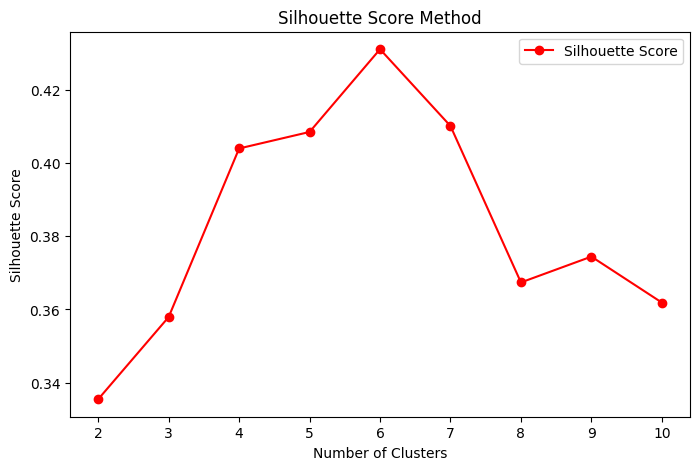

In [18]:
# Plotting the Silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', label='Silhouette Score', color='red')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Method')
plt.legend()
plt.show()

In [19]:
# Optimal clusters based on Silhouette scores
optimal_silhouette_clusters = silhouette_scores.index(max(silhouette_scores)) + 2
print(f'Optimal Number of Clusters based on Silhouette Score: {optimal_silhouette_clusters}')

Optimal Number of Clusters based on Silhouette Score: 6


In [20]:
# K-Means clustering
optimal_clusters = max(5, optimal_silhouette_clusters)

kmeans = KMeans(n_clusters = optimal_clusters, random_state = 42)
df['Cluster_KMeans'] = kmeans.fit_predict(df_scaled)

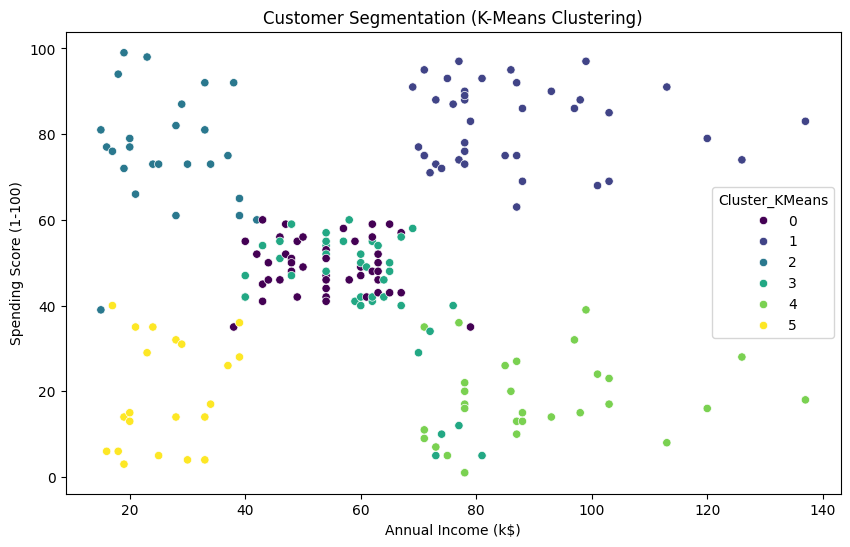

In [21]:
# Visualise clusters
plt.figure (figsize = (10, 6))
sns.scatterplot (data = df, x ='Annual Income (k$)', y = 'Spending Score (1-100)', hue = 'Cluster_KMeans', palette = 'viridis')
plt.title ('Customer Segmentation (K-Means Clustering)')
plt.show()

In [22]:
# Evaluate K-Means clustering

from sklearn.metrics import davies_bouldin_score

sil_kmeans = silhouette_score(df_scaled, df['Cluster_KMeans'])
db_kmeans = davies_bouldin_score(df_scaled, df['Cluster_KMeans'])
print(f"K-Means: Silhouette Score = {sil_kmeans:.3f}, Davies-Bouldin Index = {db_kmeans:.3f}")

K-Means: Silhouette Score = 0.431, Davies-Bouldin Index = 0.835


### Hierarchial Clustering

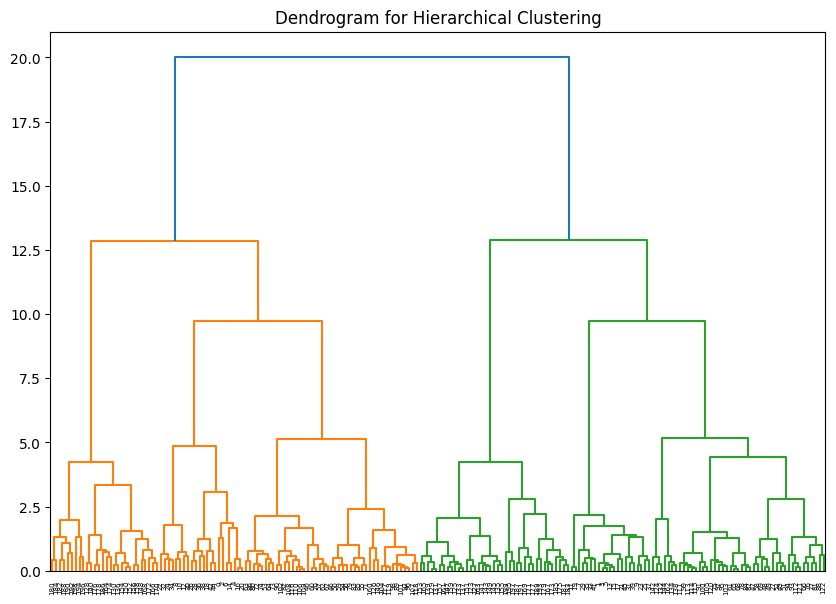

In [23]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

Z = linkage(df_scaled, method='ward') # linkage matrix
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Dendrogram for Hierarchical Clustering')
plt.show()

In [24]:
df['Cluster_HC'] = fcluster(Z, t = optimal_clusters, criterion = 'maxclust')

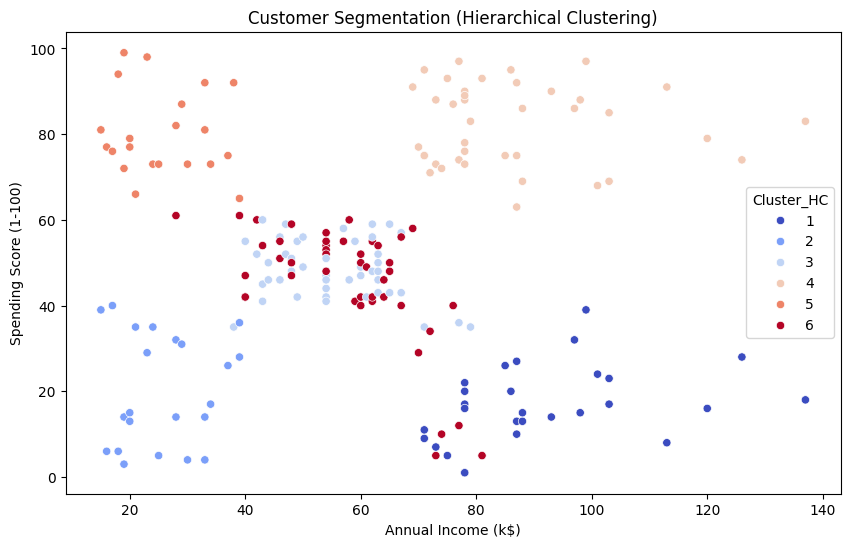

In [25]:
# Visualize Hierarchical clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster_HC', palette='coolwarm')
plt.title('Customer Segmentation (Hierarchical Clustering)')
plt.show()

In [26]:
# Evaluate Hierarchical clustering
sil_hc = silhouette_score(df_scaled, df['Cluster_HC'])
db_hc = davies_bouldin_score(df_scaled, df['Cluster_HC'])
print(f"Hierarchical Clustering: Silhouette Score = {sil_hc:.3f}, Davies-Bouldin Index = {db_hc:.3f}")

Hierarchical Clustering: Silhouette Score = 0.420, Davies-Bouldin Index = 0.852


### DBSCAN Clustering

In [27]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN (eps = 0.5, min_samples=5)

df['Cluster_DBSCAN'] = dbscan.fit_predict (df_scaled)

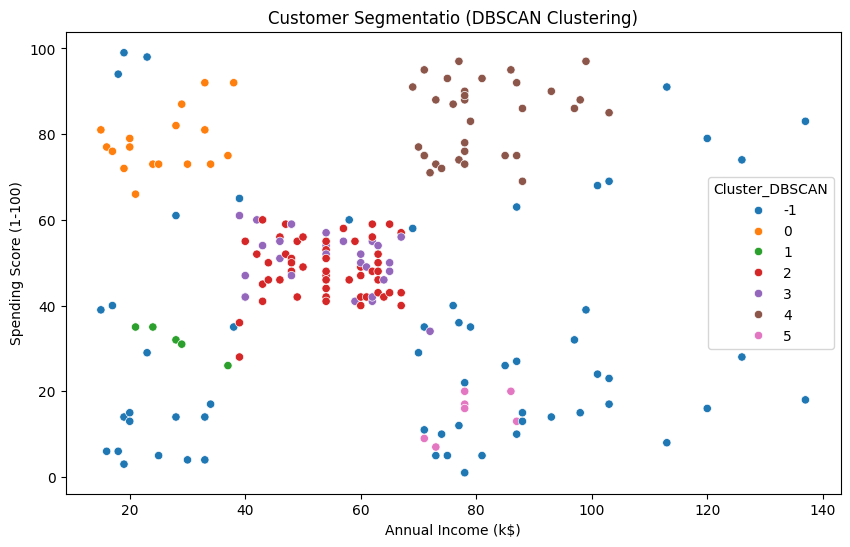

In [28]:
# Visualise DBSCAN clusters

plt.figure (figsize = (10, 6))
sns.scatterplot (data = df, x = 'Annual Income (k$)', y = 'Spending Score (1-100)', hue = 'Cluster_DBSCAN', palette='tab10')
plt.title ('Customer Segmentatio (DBSCAN Clustering)')
plt.show()

In [42]:
# Evaluate DBSCAN
sil_dbscan = silhouette_score(df_scaled, df['Cluster_DBSCAN'])
db_dbscan = davies_bouldin_score(df_scaled, df['Cluster_DBSCAN'])
print(f"DBSCAN Clustering: Silhouette Score = {sil_dbscan:.3f}, Davies-Bouldin Index = {db_dbscan:.3f}")

DBSCAN Clustering: Silhouette Score = 0.185, Davies-Bouldin Index = 1.757


### Ensemble Clustering (Consensus Clustering)

In [29]:
base_labels = []

In [30]:
# Add K-Means with varying clusters
for n_clusters in range (2, 6) :
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    base_labels.append(kmeans.fit_predict (df_scaled))


In [31]:
# Add Hierarchical Clustering with different linkage methods
from sklearn.cluster import AgglomerativeClustering

for linkage_method in ['single', 'complete', 'average', 'ward'] :
    hc = AgglomerativeClustering (n_clusters=5, linkage=linkage_method)
    base_labels.append (hc.fit_predict (df_scaled))


In [32]:
# Add DBSCAN with varying epsilon values
for epsilon_values in [0.3, 0.5, 0.7] :
    dbscan = DBSCAN (eps = epsilon_values, min_samples=5)
    base_labels.append (dbscan.fit_predict (df_scaled))


In [35]:
# Co-association matrix from the above clustering algorithms
n_samples = df_scaled.shape[0]
co_assoc_matrix = np.zeros ((n_samples, n_samples))

for labels in base_labels :
    for i in range (n_samples) :
        for j in range (n_samples) :
            # If points i and j are in the same cluster and not labeled as noise
            if labels[i] == labels[j] and labels[i] != -1 :
                # co-association count for the pair (i, j) is incremented by 1
                co_assoc_matrix[i, j] += 1


In [36]:
# Normalise co-association matrix
co_assoc_matrix /= len(base_labels)

In [38]:
ensemble_clustering = AgglomerativeClustering(n_clusters=5, metric='precomputed', linkage='average')

df['Cluster_Ensemble'] = ensemble_clustering.fit_predict(1 - co_assoc_matrix)

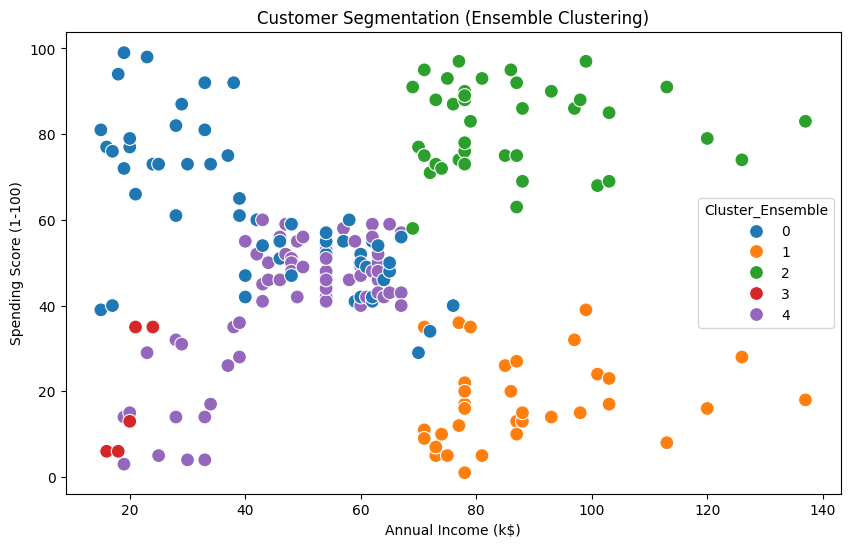

In [39]:
# Visualise Ensemble clusters
plt.figure (figsize = (10, 6))
sns.scatterplot (data = df, x = 'Annual Income (k$)', y = 'Spending Score (1-100)', hue = 'Cluster_Ensemble', palette = 'tab10', s = 100)
plt.title ('Customer Segmentation (Ensemble Clustering)')
plt.show()

In [43]:
# Evaluation of Ensemble Clustering
sil_ec = silhouette_score(df_scaled, df['Cluster_Ensemble'])
db_ec = davies_bouldin_score(df_scaled, df['Cluster_Ensemble'])
print(f"Ensemble Clustering: Silhouette Score = {sil_ec:.3f}, Davies-Bouldin Index = {db_ec:.3f}")

Ensemble Clustering: Silhouette Score = 0.373, Davies-Bouldin Index = 0.898


### Evaluation of all Clustering Methods


--- Comprehensive Evaluation of Clustering Methods ---
         Method  Silhouette Score  Davies-Bouldin Index
0       K-Means          0.431065              0.834966
1  Hierarchical          0.420117              0.852102
2        DBSCAN          0.184514              1.756946
3      Ensemble          0.373031              0.898058


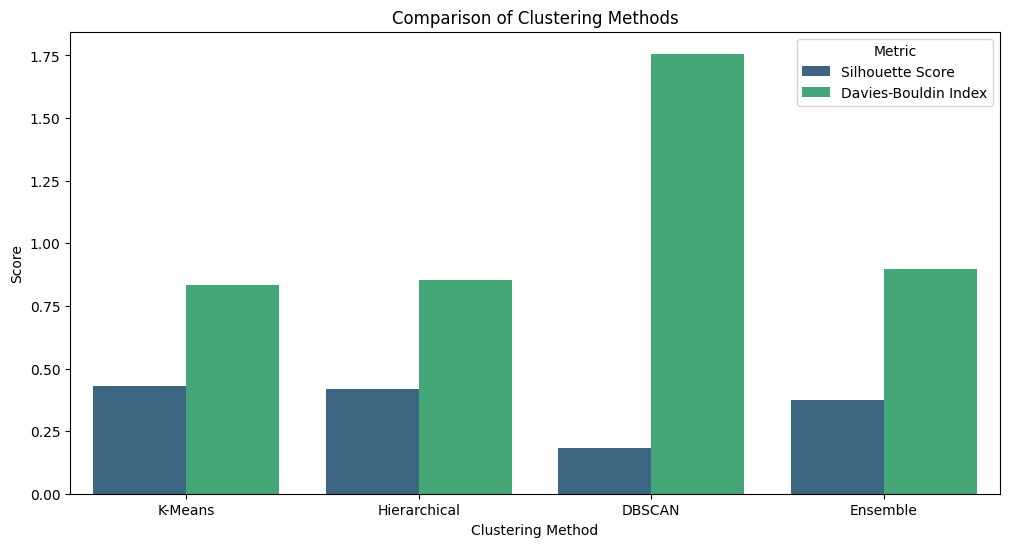

In [ ]:
print("\n--- Comprehensive Evaluation of Clustering Methods ---")

# Initialize a results dictionary to store metrics for each method
evaluation_results = {
    "Method": [],
    "Silhouette Score": [],
    "Davies-Bouldin Index": []
}

# Function to evaluate clustering results
def evaluate_clustering(method_name, data, labels):
    if len(set(labels)) > 1:  # Ensure valid clusters exist (at least 2 clusters)
        sil_score = silhouette_score(data, labels)
        db_index = davies_bouldin_score(data, labels)
    else:
        sil_score = db_index = None  # No valid clusters

    # Add results to the dictionary
    evaluation_results["Method"].append(method_name)
    evaluation_results["Silhouette Score"].append(sil_score)
    evaluation_results["Davies-Bouldin Index"].append(db_index)

# Evaluate K-Means Clustering
evaluate_clustering("K-Means", df_scaled, df['Cluster_KMeans'])

# Evaluate Hierarchical Clustering
evaluate_clustering("Hierarchical", df_scaled, df['Cluster_HC'])

# Evaluate DBSCAN Clustering
evaluate_clustering("DBSCAN", df_scaled, df['Cluster_DBSCAN'])

# Evaluate Ensemble Clustering
evaluate_clustering("Ensemble", df_scaled, df['Cluster_Ensemble'])

# Display the results as a DataFrame
evaluation_df = pd.DataFrame(evaluation_results)
print(evaluation_df)

# Visualize the results
plt.figure(figsize=(12, 6))
sns.barplot(data=evaluation_df.melt(id_vars="Method"),
            x="Method", y="value", hue="variable", palette="viridis")
plt.title("Comparison of Clustering Methods")
plt.ylabel("Score")
plt.xlabel("Clustering Method")
plt.legend(title="Metric")
plt.show()

Here, in terms of performance, we see : K-Means > Hierarchical > Ensemble Clustering > DBSCAN